In [1]:
import os
import meshio
from dctkit.mesh import util
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import plotly.io as pio
import plotly.graph_objects as go
import dctkit as dt
from functools import partial
from dctkit.math.opt import optctrl as oc
from dctkit.dec import cochain as C
import jax.numpy as jnp
from scipy.sparse import coo_matrix, csr_matrix, diags
from scipy.sparse.linalg import spsolve
from matplotlib import cm
from matplotlib.colors import LightSource

In [2]:
dt.config()

In [3]:
# load stanford bunny
filename = "data/stanford-bunny.obj"
mesh = meshio.read(
    filename)
S = util.build_complex_from_mesh(mesh, 3)
S.get_hodge_star()
S.get_complex_boundary_simplices_indices()

In [4]:
node_coords = S.node_coords  # shape (N, 3)
num_nodes = S.num_nodes

In [5]:
k = 1.

# --- Define exact solution u_true = x^2 + y^2 on the hemisphere ---
# On the unit hemisphere: x^2 + y^2 = 1 - z^2, z in [0, 1]
u_true = np.array(
    node_coords[:, 0]**2 + node_coords[:, 1]**2,
    dtype=dt.float_dtype
)

# --- Identify boundary nodes (equatorial circle, where z ~ 0) ---
# On the hemisphere generated by gmsh with angle3=pi/2, the boundary
# is the equatorial circle at z = 0.
bnodes = S.boundary_simplices[0]
b_values = u_true[bnodes]
boundary_values = (np.array(bnodes, dtype=dt.int_dtype), b_values)

print(f"Num nodes: {num_nodes}, Num boundary nodes: {len(bnodes)}")

# --- Forcing term ---
u_coch = C.CochainP0(S,u_true)
f_vec = -k*C.coboundary(C.star(C.coboundary(u_coch))).coeffs

# Mask: zero at boundary nodes 
mask = np.ones((num_nodes, 1), dtype=dt.float_dtype)
mask[bnodes, :] = 0.

# --- Initial guess ---
np.random.seed(42)
u_0 = 0.01*np.random.rand(num_nodes).astype(dt.float_dtype)

# --- Objective: residual of k*Delta u + f = 0, plus boundary penalty ---
gamma = 100.

Num nodes: 34834, Num boundary nodes: 223


In [6]:
#NOTE: uncomment if the surface is without boundary
# Pick node 0 as your "anchor" to pin the floating constant
# anchor_idx = np.array([0], dtype=dt.int_dtype)
# anchor_val = np.array([u_true[0]], dtype=dt.float_dtype)

# # Update your boundary values for the solver
# boundary_values = (anchor_idx, anchor_val)

In [7]:
# build laplacian
boundary_0_coo = S.boundary[1]
boundary_0 = coo_matrix(
    (boundary_0_coo[2], (boundary_0_coo[0], boundary_0_coo[1])),
    shape=(S.num_nodes, S.S[1].shape[0]),
).tocsr()
hodge_1 = diags(S.hodge_star[1], offsets=0, format="csr")
L = boundary_0 @ hodge_1 @ boundary_0.T

In [8]:
# Apply Dirichlet boundary conditions
mask = np.ones(num_nodes, dtype=bool)
mask[boundary_values[0]] = False

In [9]:
# Split system into interior and boundary
L_int = L[mask][:, mask]
f_int = f_vec.flatten()[mask] - L[mask][:, ~mask] @ boundary_values[1]

# Solve linear system
print("Solving linear system...")
u_int = spsolve(L_int, f_int)

# Combine solution
u_comp = np.zeros(num_nodes, dtype=dt.float_dtype)
u_comp[mask] = u_int
u_comp[~mask] = boundary_values[1]

Solving linear system...


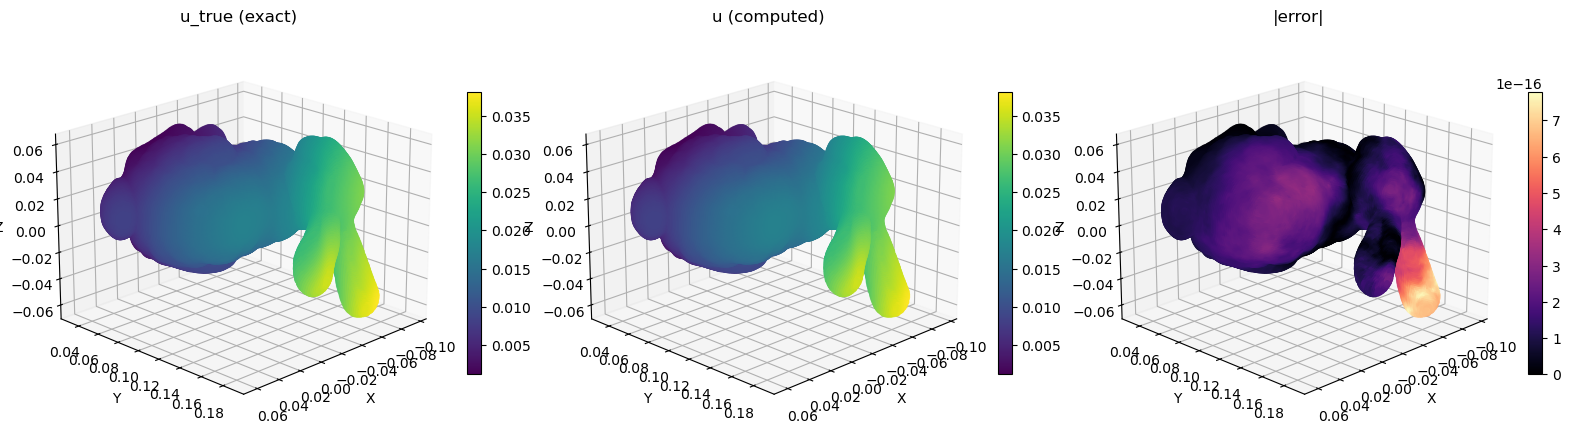

In [10]:
# --- Plot result ---
fig = plt.figure(figsize=(16, 5))

# Define the global scale based on u_true to keep the colorbar consistent
v_min, v_max = np.min(u_true), np.max(u_true)

for idx, (values, title) in enumerate(zip(
    [u_true, u_comp, np.abs(u_comp - u_true)],
    ["u_true (exact)", "u (computed)", "|error|"]
)):
    ax = fig.add_subplot(1, 3, idx + 1, projection='3d')
    
    # Use vmin and vmax for the first two plots (u_true and u_comp)
    # The error plot should usually stay autoscaled to see the distribution of noise
    if idx < 2:
        sc = ax.scatter(
            node_coords[:, 0], node_coords[:, 1], node_coords[:, 2],
            c=values, cmap='viridis', s=10, vmin=v_min, vmax=v_max
        )
    else:
        sc = ax.scatter(
            node_coords[:, 0], node_coords[:, 1], node_coords[:, 2],
            c=values, cmap='magma', s=10  # 'magma' or 'inferno' is often better for error
        )
        
    plt.colorbar(sc, ax=ax, shrink=0.6)
    ax.set_title(title)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.view_init(elev=20, azim=45) # Optional: keeps the bunny angle consistent

plt.tight_layout()
plt.show()

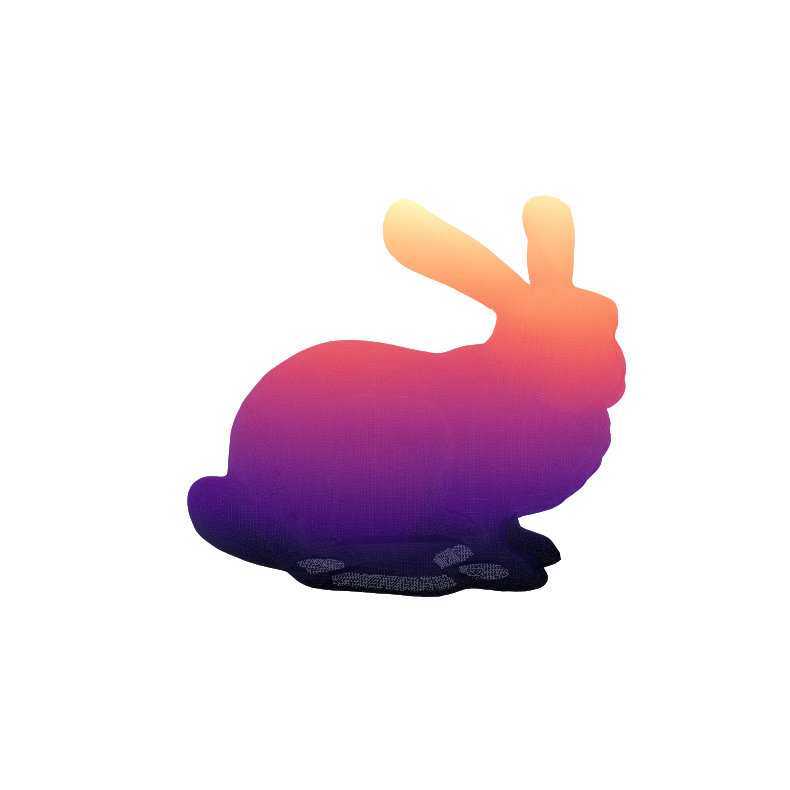

In [11]:
# --- Beautiful Upright Plot ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Data extraction
x, y, z = node_coords[:, 0], node_coords[:, 1], node_coords[:, 2]
triangles = S.S[2]

# Light source for 3D depth
ls = LightSource(azdeg=180, altdeg=45)
cmap = cm.get_cmap('magma')

# Plotting with trisurf
# Note: If the bunny still looks 'lying down', swap (x, y, z) to (x, z, y) below
surf = ax.plot_trisurf(
    x, z, y, # Swapped these two
    triangles=triangles, 
    cmap=cmap, 
    antialiased=True
)

# --- ROTATION TO PUT LEGS ON GROUND ---
# elev: elevation angle (0 is horizon, 90 is top-down)
# azim: rotation around the Z-axis
ax.view_init(elev=10, azim=90) 

# Clean up visual noise
ax.set_axis_off() 
fig.patch.set_facecolor('white') # Clean background


plt.show()